# 2026 Cryo-EM Candidate Dataset — Exploratory Data Analysis

Purpose: look at what the filtered candidate pool actually contains before doing the stratified sample-down to the ~10–15 benchmark maps. Covers the pipeline funnel, resolution, release timeline, polymer composition, reconstruction method, and protein size — the dimensions the stratified sample needs to cover deliberately rather than by luck.

Inputs (all produced by the three filter scripts, see `CLAUDE.md` for the full pipeline log):
- `rcsb_2026_cryoem_candidates.csv` — stage 1 raw candidates (5,163)
- `rcsb_2026_pure_protein.csv` — stage 2, pure-protein + single-particle (3,752)
- `rcsb_2026_final_candidates.csv` — stage 3, + EMDB map release-date verified (3,745) — **the final vetted pool**
- `pdb_id_entry_size.csv` — residue/chain counts for the final pool, fetched separately (RCSB doesn't return this from the stage-1/2/3 queries)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# dataviz skill palette (see ~/.claude/skills/dataviz) — categorical hues in fixed
# order (never cycled/reassigned), single-hue sequential for magnitude, no dual axes.
CATEGORICAL = ["#2a78d6", "#008300", "#e87ba4", "#eda100", "#1baf7a", "#eb6834", "#4a3aa7", "#e34948"]
SEQ_BLUE = "#2a78d6"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": GRIDLINE,
    "font.family": "sans-serif",
    "font.size": 11,
})

def style_ax(ax, ygrid=True):
    if ygrid:
        ax.yaxis.grid(True, linewidth=0.8)
        ax.set_axisbelow(True)
    ax.spines["left"].set_color(BASELINE)
    ax.spines["bottom"].set_color(BASELINE)

In [2]:
raw = pd.read_csv("rcsb_2026_cryoem_candidates.csv")
pure_protein = pd.read_csv("rcsb_2026_pure_protein.csv")
final = pd.read_csv("rcsb_2026_final_candidates.csv")
size = pd.read_csv("pdb_id_entry_size.csv")

final["release_date"] = pd.to_datetime(final["release_date"])
df = final.merge(size, on="pdb_id", how="left")

print(f"stage 1 (raw 2026 EM candidates):              {len(raw):>5}")
print(f"stage 2 (pure protein + single particle):       {len(pure_protein):>5}")
print(f"stage 3 (+ EMDB map release-date verified):     {len(final):>5}  <- final pool")
print(f"missing size data after merge:                  {df['residue_count'].isna().sum():>5}")
df.head()

stage 1 (raw 2026 EM candidates):               5163
stage 2 (pure protein + single particle):        3752
stage 3 (+ EMDB map release-date verified):      3745  <- final pool
missing size data after merge:                      0


,pdb_id,emdb_ids,resolution,release_date,title,polymer_composition,reconstruction_method,emdb_map_release_dates,emdb_map_release_ok,residue_count,chain_count,protein_entity_count
0,10AC,EMD-75023,2.47,2026-08-12 00:00:00+00:00,Cryo-EM structure of major outer membrane prot...,homomeric protein,SINGLE PARTICLE,2026-08-12,True,1206,3,1
1,10AD,EMD-75024,3.44,2026-02-04 00:00:00+00:00,Cryo-EM structure of the human BK channel boun...,homomeric protein,SINGLE PARTICLE,2026-02-04,True,3496,4,1
2,10AL,EMD-75028,2.45,2026-09-16 00:00:00+00:00,indoleacetate decarboxylase with bound indole-...,homomeric protein,SINGLE PARTICLE,2026-09-16,True,3500,4,1
3,10AM,EMD-75029,3.13,2026-08-12 00:00:00+00:00,C. Jejuni Simpl-Like Protein,homomeric protein,SINGLE PARTICLE,2026-08-12,True,2079,9,1
4,10AW,EMD-75037,2.82,2026-08-12 00:00:00+00:00,Cryo-EM structure of 50 kDa outer membrane pro...,homomeric protein,SINGLE PARTICLE,2026-08-12,True,1314,3,1


## Pipeline funnel

How much each filter stage actually removed. Composition + reconstruction-method are the big cuts (ribosomes/spliceosomes/nucleosomes and helical/subtomogram maps); the EMDB release-date check is a small but important correction (7 stale-map false positives caught after the fact).

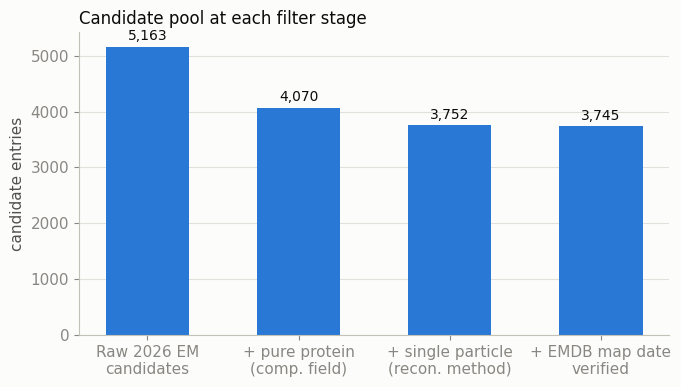

In [3]:
stages = ["Raw 2026 EM\ncandidates", "+ pure protein\n(comp. field)", "+ single particle\n(recon. method)", "+ EMDB map date\nverified"]
counts = [len(raw), (raw["pdb_id"].isin(pd.read_csv("pdb_id_polymer_composition.csv").query(
    "polymer_composition in ['homomeric protein','heteromeric protein','protein/oligosaccharide']")["pdb_id"])).sum(),
    len(pure_protein), len(final)]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(stages, counts, color=SEQ_BLUE, width=0.55, edgecolor="none")
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, c + 60, f"{c:,}", ha="center", va="bottom", color=INK_PRIMARY, fontsize=10)
style_ax(ax)
ax.set_ylabel("candidate entries")
ax.set_title("Candidate pool at each filter stage", color=INK_PRIMARY, fontsize=12, loc="left")
plt.tight_layout()
plt.show()

## Resolution distribution (final pool)

Should sit entirely inside [1.5, 4.0] Å by construction (stage-1 filter) — confirming that here, plus seeing where the mass actually concentrates, matters for picking a resolution-stratified sample rather than one that's accidentally all 3.5–4.0 Å.

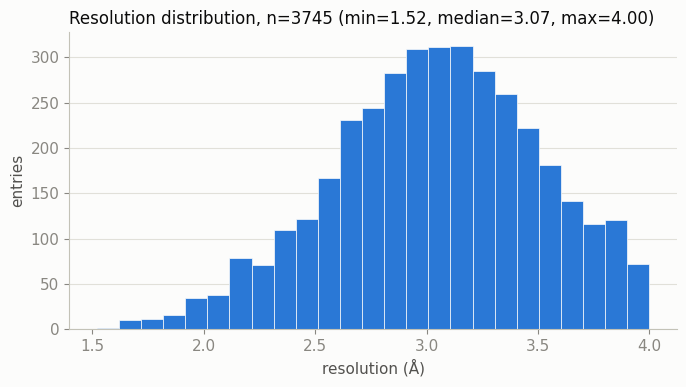

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["resolution"], bins=25, color=SEQ_BLUE, edgecolor=SURFACE, linewidth=0.5)
style_ax(ax)
ax.set_xlabel("resolution (\u00c5)")
ax.set_ylabel("entries")
ax.set_title(f"Resolution distribution, n={len(df)} (min={df['resolution'].min():.2f}, "
             f"median={df['resolution'].median():.2f}, max={df['resolution'].max():.2f})",
             color=INK_PRIMARY, fontsize=12, loc="left")
plt.tight_layout()
plt.show()

## Release timeline

PDB release date, by month, for the final pool — confirms coverage across the full 2026 window rather than a lopsided burst in one month.

/var/folders/9q/w7dg5r0s76sb6z8r8j3k4ll80000gn/T/ipykernel_75973/3818579421.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = df["release_date"].dt.to_period("M").value_counts().sort_index()


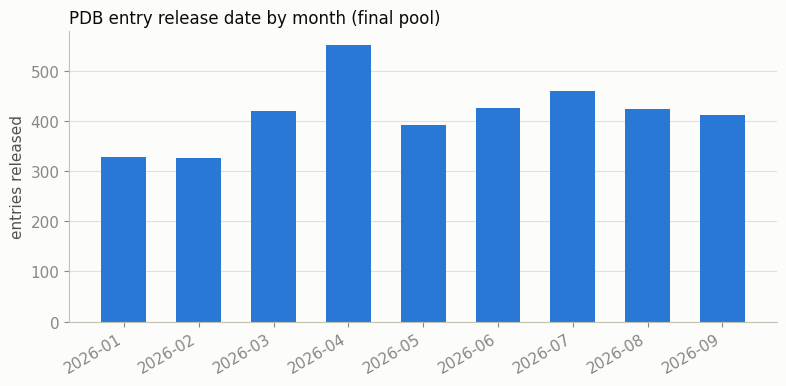

In [5]:
monthly = df["release_date"].dt.to_period("M").value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(monthly.index.astype(str), monthly.values, color=SEQ_BLUE, width=0.6)
style_ax(ax)
ax.set_ylabel("entries released")
ax.set_title("PDB entry release date by month (final pool)", color=INK_PRIMARY, fontsize=12, loc="left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Polymer composition (stage-1 pool, before the composition filter)

Shown on the *raw* 5,163 to make visible what the composition filter actually removed — `protein/NA` is where every ribosome, spliceosome, nucleosome, and CRISPR-Cas effector complex was sitting, not caught by a title-keyword search.

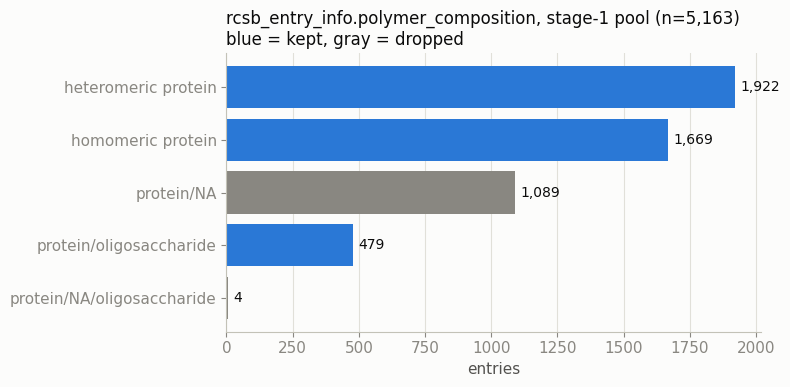

In [6]:
comp = pd.read_csv("pdb_id_polymer_composition.csv")
comp_counts = comp["polymer_composition"].value_counts()
kept_mask = comp_counts.index.isin(["homomeric protein", "heteromeric protein", "protein/oligosaccharide"])
colors = [CATEGORICAL[0] if k else INK_MUTED for k in kept_mask]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(comp_counts.index[::-1], comp_counts.values[::-1], color=colors[::-1])
for b, c in zip(bars, comp_counts.values[::-1]):
    ax.text(c + 20, b.get_y() + b.get_height()/2, f"{c:,}", va="center", color=INK_PRIMARY, fontsize=10)
style_ax(ax, ygrid=False)
ax.xaxis.grid(True, linewidth=0.8)
ax.set_axisbelow(True)
ax.set_xlabel("entries")
ax.set_title("rcsb_entry_info.polymer_composition, stage-1 pool (n=5,163)\nblue = kept, gray = dropped",
             color=INK_PRIMARY, fontsize=12, loc="left")
plt.tight_layout()
plt.show()

## Reconstruction method (pure-protein pool, before the single-particle filter)

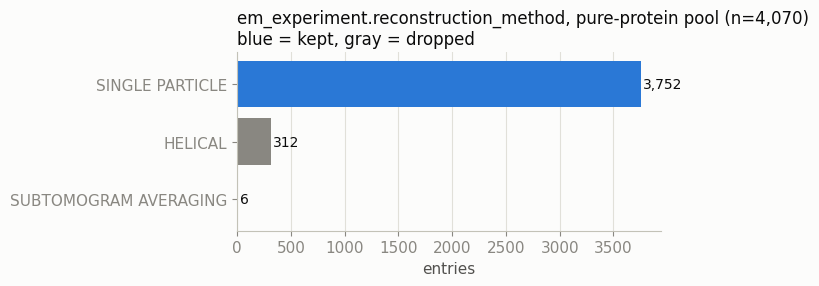

In [7]:
recon = pd.read_csv("pdb_id_reconstruction_method.csv")
recon_counts = recon["reconstruction_method"].value_counts()
colors = [CATEGORICAL[0] if k == "SINGLE PARTICLE" else INK_MUTED for k in recon_counts.index]

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(recon_counts.index[::-1], recon_counts.values[::-1], color=colors[::-1])
for b, c in zip(bars, recon_counts.values[::-1]):
    ax.text(c + 20, b.get_y() + b.get_height()/2, f"{c:,}", va="center", color=INK_PRIMARY, fontsize=10)
style_ax(ax, ygrid=False)
ax.xaxis.grid(True, linewidth=0.8)
ax.set_axisbelow(True)
ax.set_xlabel("entries")
ax.set_title("em_experiment.reconstruction_method, pure-protein pool (n=4,070)\nblue = kept, gray = dropped",
             color=INK_PRIMARY, fontsize=12, loc="left")
plt.tight_layout()
plt.show()

## Protein size (final pool)

`residue_count` = `deposited_modeled_polymer_monomer_count` (total modeled residues across all chains — the same size notion the paper uses for its "protein length" robustness analysis, Fig. 7). Heavily right-skewed — log-scale x-axis, and the max is a 589-chain, 201k-residue outlier (almost certainly a viral capsid or large filament) that's automatically out of scope for a 10–15-map benchmark on free-tier compute regardless of resolution.

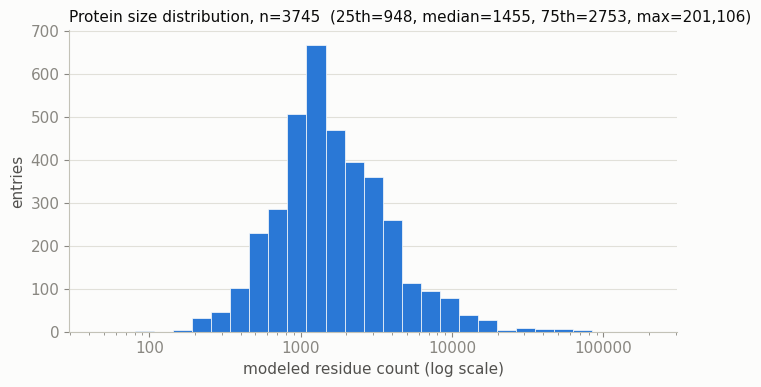

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.logspace(np.log10(df["residue_count"].min()), np.log10(df["residue_count"].max()), 30)
ax.hist(df["residue_count"], bins=bins, color=SEQ_BLUE, edgecolor=SURFACE, linewidth=0.5)
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
style_ax(ax)
ax.set_xlabel("modeled residue count (log scale)")
ax.set_ylabel("entries")
q = df["residue_count"].quantile([0.25, 0.5, 0.75])
ax.set_title(f"Protein size distribution, n={len(df)}  (25th={q[0.25]:.0f}, median={q[0.5]:.0f}, 75th={q[0.75]:.0f}, max={df['residue_count'].max():,})",
             color=INK_PRIMARY, fontsize=11, loc="left")
plt.tight_layout()
plt.show()

## Size vs. resolution — the actual sampling space

This is the joint distribution the stratified sample needs to cover. Overlaid lines mark a practical 3×3 grid (size × resolution tertiles) as candidate strata for picking the ~10–15 benchmark maps — next step is sampling 1–2 maps per cell, weighted toward the cells with more candidates to choose from.

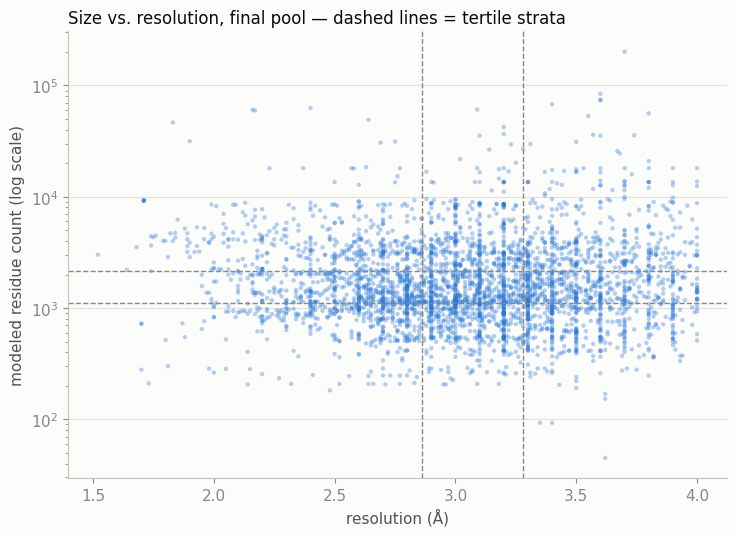

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.scatter(df["resolution"], df["residue_count"], s=10, color=SEQ_BLUE, alpha=0.35, edgecolor="none")
ax.set_yscale("log")

res_terts = df["resolution"].quantile([1/3, 2/3]).values
size_terts = df["residue_count"].quantile([1/3, 2/3]).values
for x in res_terts:
    ax.axvline(x, color=INK_MUTED, linestyle="--", linewidth=1)
for y in size_terts:
    ax.axhline(y, color=INK_MUTED, linestyle="--", linewidth=1)

style_ax(ax)
ax.set_xlabel("resolution (\u00c5)")
ax.set_ylabel("modeled residue count (log scale)")
ax.set_title("Size vs. resolution, final pool — dashed lines = tertile strata", color=INK_PRIMARY, fontsize=12, loc="left")
plt.tight_layout()
plt.show()

## Candidate count per stratum

How many entries fall in each of the 9 size×resolution cells — tells us which strata are candidate-rich (easy to pick a good representative) vs. candidate-poor (may need to relax that cell's bounds when we actually sample).

In [10]:
size_bins = pd.qcut(df["residue_count"], 3, labels=["small", "medium", "large"])
res_bins = pd.qcut(df["resolution"], 3, labels=["high-res", "mid-res", "low-res"])
strata = pd.crosstab(size_bins, res_bins)

size_ranges = df.groupby(size_bins)["residue_count"].agg(["min", "max"])
res_ranges = df.groupby(res_bins)["resolution"].agg(["min", "max"])
print("size bin ranges (residues):\n", size_ranges, "\n")
print("resolution bin ranges (\u00c5):\n", res_ranges, "\n")
strata

size bin ranges (residues):
                 min     max
residue_count              
small            45    1108
medium         1111    2129
large          2130  201106 

resolution bin ranges (Å):
              min   max
resolution            
high-res    1.52  2.86
mid-res     2.87  3.28
low-res     3.29  4.00 



/var/folders/9q/w7dg5r0s76sb6z8r8j3k4ll80000gn/T/ipykernel_75973/1537965348.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_ranges = df.groupby(size_bins)["residue_count"].agg(["min", "max"])
/var/folders/9q/w7dg5r0s76sb6z8r8j3k4ll80000gn/T/ipykernel_75973/1537965348.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res_ranges = df.groupby(res_bins)["resolution"].agg(["min", "max"])


resolution,high-res,mid-res,low-res
residue_count,,,
small,404,443,402
medium,438,399,410
large,422,403,424


## Refined resolution bins — driven by the actual distribution shape

The resolution histogram above is right-skewed with a thin tail below 2.0 Å (~2.7%
of the pool). A blind tertile split buries that tail inside a "high-res" bucket
that actually only reaches ~2.86 Å (see the tertile ranges printed above) — so a
sample built on tertiles alone would never include a genuinely near-atomic map.

Switching to **absolute resolution cutoffs** that reflect where the mass actually
sits, so near-atomic gets deliberate representation instead of disappearing:

- **near-atomic**: < 2.2 Å (the thin tail)
- **high**: 2.2–2.8 Å
- **mid**: 2.8–3.4 Å (where the peak sits)
- **low**: 3.4–4.0 Å

Crossed with the 3 size tertiles (unchanged — size doesn't have the same skew
problem), that's a 4×3 = 12-cell grid, which conveniently lands at the target
n and mirrors the paper's own `test_2025` count (12 maps).

In [11]:
res_edges = [1.5, 2.2, 2.8, 3.4, 4.0]
res_labels_v2 = ["near-atomic (<2.2)", "high (2.2-2.8)", "mid (2.8-3.4)", "low (3.4-4.0)"]
df["res_bin_v2"] = pd.cut(df["resolution"], bins=res_edges, labels=res_labels_v2, include_lowest=True)

cell_counts = pd.crosstab(size_bins, df["res_bin_v2"])
print(cell_counts)
print("\ntotal:", cell_counts.values.sum(), " | smallest cell:", cell_counts.values.min())

res_bin_v2     near-atomic (<2.2)  high (2.2-2.8)  mid (2.8-3.4)  \
residue_count                                                      
small                          46             316            624   
medium                         41             345            586   
large                         100             285            549   

res_bin_v2     low (3.4-4.0)  
residue_count                 
small                    263  
medium                   275  
large                    315  

total: 3745  | smallest cell: 41


## Shortlist: one candidate per cell

Every cell has ≥41 candidates — no starved corners forcing a compromise pick.
Selection rule per cell (purposive, not random — see `CLAUDE.md` for why that's
the right call at n=12): prefer a **tractable chain count (2–6)**, i.e. a real
multi-chain complex (the thing MICA/ModelAngelo/EModelX(+AF)/CryoAtom are
actually built to handle, and the thing the paper's own Discussion flags as the
hard part — chain/sequence registration across multiple chains) that's still a
manageable number of AF3 submissions and docking complexity. Within that
tractable subset, pick the entry closest to the cell's median resolution, as a
"typical for this cell" tie-break rather than an edge case.

This is v1 — flagged for manual review before locking in: `9OVN` (near-atomic/
large) is the only sub-2.0 Å pick, worth checking it has a complete deposited
model; any entry here can be swapped for the next-best in its cell if the title
reveals something that complicates the pipeline (engineered fusion constructs,
heavy mutation, etc).

In [12]:
size_labels = ["small", "medium", "large"]
res_labels_order = ["near-atomic (<2.2)", "high (2.2-2.8)", "mid (2.8-3.4)", "low (3.4-4.0)"]

picks = []
for sb in size_labels:
    for rb in res_labels_order:
        cell = df[(size_bins == sb) & (df["res_bin_v2"] == rb)]
        tractable = cell[cell["chain_count"].between(2, 6)]
        pool = tractable if len(tractable) >= 2 else cell
        pool = pool.assign(res_dist=(pool["resolution"] - pool["resolution"].median()).abs())
        top = pool.sort_values("res_dist").head(1)
        picks.append(top.assign(size_bin=sb, res_bin=rb))

shortlist = pd.concat(picks)[
    ["pdb_id", "size_bin", "res_bin", "resolution", "residue_count", "chain_count", "emdb_ids", "title"]
]
shortlist.to_csv("shortlist_12_v1.csv", index=False)
shortlist

,pdb_id,size_bin,res_bin,resolution,residue_count,chain_count,emdb_ids,title
2850,9W0J,small,near-atomic (<2.2),2.09,829,5,EMD-65506,CryoEM structure of EV-D68 strain Fermon in co...
1125,9LL8,small,high (2.2-2.8),2.62,882,4,EMD-63193,Psilocin-bound Serotonin 2A (5-HT2A) receptor-...
1309,9MUH,small,mid (2.8-3.4),3.10,498,2,EMD-48632,Mus musculus TASK-1 (KCNK3) in MSP1E3D1 lipid ...
3494,9YSR,small,low (3.4-4.0),3.63,757,2,EMD-73426,Local refinement of hACE2/SARS-CoV-2 BA.3.2.1 ...
165,11NW,medium,near-atomic (<2.2),2.16,1372,4,EMD-75873,Rabbit muscle Aldolase (C1 symmetry) determine...
494,24RC,medium,high (2.2-2.8),2.61,1252,2,EMD-69776,Cryo-EM structure of human sodium pump W931R m...
2008,9RGN,medium,mid (2.8-3.4),3.10,1655,5,EMD-53951,SsCl at pH 6.5 + IVM - Partially opened
657,30FM,medium,low (3.4-4.0),3.60,2100,3,EMD-57539,Structure of histone H1 in an import-chaperone...
1611,9OVN,large,near-atomic (<2.2),1.93,3594,3,EMD-70903,Cryo-EM structure of HCoV-OC43-C2 Spike glycop...
1387,9NI4,large,high (2.2-2.8),2.61,2180,4,EMD-49452,Cryo-EM structure of the PI3K alpha/KRas/HER3 ...
